# Proyecto final de aprendizaje automático

In [343]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
import pickle
import json

## Paso 1: Definición del problema

### Objetivo: 
- Predecir la demanda futura de productos farmacéuticos para optimizar la gestión de inventario.
- Evitar quiebres de stock y sobrestock. 
- Reducir pérdida por vencimientos y mejorar disponibilidad.
##### Plan B: Predecir el total que abonará el cliente en una transacción, considerando cantidad, producto, rubro, cobertura, descuentos e impuestos.

## Paso 2: Obtencion y carga del conjunto de datos

In [274]:
df = pd.read_csv('../data/raw/farmacia-datos.csv', sep=';',encoding='latin-1')
df.head(12)

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0.0,0,9344,0,0.0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0.0,0,"5142,11",0,0.0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0.0,0,"2856,86",0,0.0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0.0,0,"8086,82",0,0.0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0.0,0,"26750,12",0,0.0,0,"26750,12"
5,01/01/25 06.06.42,F,B,0,379928,NaN,E,1,"24480,51",EVATEST DIGITAL env.x 1,"24480,51",FARMACIA,0,0.0,0,"24480,51","4248,683554",21.0,"20231,82645",0
6,01/01/25 06.22.37,F,B,0,379929,NaN,E,1,4800,GEN LP KETOROLAC blister 20 mg x 10,4800,FARMACIA,0,0.0,0,4800,0,0.0,0,4800
7,01/01/25 06.22.37,F,B,0,379929,NaN,E,1,4961,CAFIASPIRINA PLUS comp.x 20,4961,FARMACIA,0,0.0,0,4961,0,0.0,0,4961
8,01/01/25 07.46.36,F,B,0,379930,NaN,E,2,3500,ACCESORIO (unica),7000,FARMACIA,0,0.0,0,7000,"1214,876033",21.0,"5785,123967",0
9,02/01/25 08.08.38,F,B,0,379931,NaN,E,1,3430,QURA PLUS comp.rec.x 20,3430,FARMACIA,0,0.0,343,3087,0,0.0,0,3430


> Los datos provienen de un archivo Excel extraído del sistema de facturación de una farmacia real, convertido posteriormente a formato CSV para su procesamiento.

## Paso 3: Almacenar la información

In [275]:
df.columns = df.columns.str.replace('.', '', regex=False).str.replace(' ', '_')

Para la ejecución de las consultas SQL se normalizaron los nombres de columnas para garantizar la correcta agregación de variables numéricas.

In [276]:
# Create connection to SQLite
conn = sqlite3.connect('farmacia-datos.db')

In [277]:
# Save table
df.to_sql('ventas', conn, if_exists='replace', index=False)

117416

In [278]:
# Verify that the table exists
query = 'SELECT * FROM ventas LIMIT 5;'
pd.read_sql(query, conn)

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,01/01/25 01.13.46,F,B,0,379923,None,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0.0,0,9344,0,0.0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,None,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0.0,0,"5142,11",0,0.0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,None,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0.0,0,"2856,86",0,0.0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,None,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0.0,0,"8086,82",0,0.0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,None,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0.0,0,"26750,12",0,0.0,0,"26750,12"


**Top 10 productos más vendidos**

In [279]:
# Execute a real SQL query
query_top_10 = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto
ORDER BY Demanda_total DESC
LIMIT 10;
'''
pd.read_sql(query_top_10, conn)

,Producto,Demanda_total
0,BUSCAPINA COMPOSITUM comp.rec.x 20,2648
1,QURA PLUS comp.rec.x 20,2602
2,GEN LP IBUPROFENO blister 600 mg x 10,2135
3,SERTAL COMPUESTO comp.rec.x 20,1786
4,GEN LP OMEPRAZOL blister 20 mg x 15,1576
5,ALIKAL (unica),1483
6,MYLANTA EXTRA comp.mast.x 24,1278
7,ASPIRINA PREVENT comp.cub.enterica x 50,1160
8,CAFIASPIRINA comp.x 30,1041
9,TAFIROL 1G X 8 (unica),983


> Se almacenaron los datos en una base de datos SQLite y se realizaron consultas SQL desde Python para identificar productos de alta rotación y patrones de demanda.

**Demanda total por producto**

In [280]:
query_product = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto;
'''
pd.read_sql(query_product, conn)

,Producto,Demanda_total
0,None,1
1,CHUP.MANZANITA(C/DIBUJO)T/SILIC.+3M RED - ES...,1
2,(unica),4
3,0,0
4,1,1
...,...,...
7673,q,1
7674,|,1
7675,ï¿½,3
7676,ï¿½LEO Calcï¿½reo x 240 ml.,1


Esta consulta permite identificar los productos con mayor volumen de ventas acumuladas, fundamentales para la gestión de stock y la priorización de reposición.

**Demanda agregada por día**

In [281]:
query_per_day = """
SELECT strftime('%Y-%m', Fecha) AS mes, SUM("Cant") AS Demanda_mensual
FROM ventas
GROUP BY mes
ORDER BY mes;
"""

pd.read_sql(query_per_day, conn)

,mes,Demanda_mensual
0,None,160639


La agregación diaria por producto permite modelar la demanda como una serie temporal, base para la predicción de consumo futuro.

In [282]:
query_coverage = """
SELECT Cobertura, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Cobertura;
"""
pd.read_sql(query_coverage, conn)


,Cobertura,Demanda_total
0,None,1
1,"-157953,92",1
2,0,107169
3,10000,1
4,"10000,188",1
...,...,...
23017,"9993,308",1
23018,"9995,3",3
23019,"9998,392",2
23020,"9998,952",1


La presencia de cobertura médica incrementa la demanda, lo cual debe considerarse en la planificación de inventario.

## Paso 4: Realiza un análisis descriptivo

Variable clave: `Cant`

In [283]:
df['Cant'].describe()

count    117416.000000
mean          1.368118
std           1.862112
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         106.000000
Name: Cant, dtype: float64

In [284]:
average = df['Cant'].mean()
median = df['Cant'].median()
mode = df['Cant'].mode()[0]
variance = df['Cant'].var()
skewness = df['Cant'].skew()

In [285]:
print(f'Media:     {average:.2f}')
print(f'Mediana:   {median:.2f}')
print(f'Moda:      {mode:.2f}')
print(f'Varianza:  {variance:.2f}')
print(f'Asimetría: {skewness:.2f}')

Media:     1.37
Mediana:   1.00
Moda:      1.00
Varianza:  3.47
Asimetría: 12.14


- **Media** (1.37) vs **Mediana** (1.00): El hecho de que la media sea mayor que la mediana indica que la distribución está sesgada a la derecha. Mientras que la mayoría de los clientes compran solo 1 unidad (mediana), hay un grupo pequeño de transacciones con cantidades muy altas que elevan el promedio.
- **Moda** (1.00): Es el valor más frecuente. Esto confirma que el comportamiento estándar en la farmacia es la compra de una única unidad por producto (típico de medicamentos bajo receta).
- **Varianza** (3.47): La desviación estándar sería la raíz cuadrada de esto (≈1.86). Aunque la mayoría compra 1 unidad, hay una variabilidad considerable. En términos de negocio, esto sugiere que conviven dos tipos de clientes: el consumidor final (compra 1 unidad) y posiblemente clientes institucionales o crónicos (compran varias cajas o tratamientos completos).
- **Asimetría Positiva Extrema**: Un valor de 12.14 es extremadamente alto (en una distribución normal sería 0).   

Debido a esta asimetría, será necesario decidir si se eliminan esos valores extremos para entrenar el modelo de Machine Learning o si se tratan de forma especial, ya que podrían distorsionar las predicciones.

In [286]:
df.shape

(117416, 20)

In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117416 entries, 0 to 117415
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117416 non-null  object 
 1   Tipo_Mov          117416 non-null  object 
 2   Fac_Tipo          117416 non-null  object 
 3   Fac_Suc           117416 non-null  int64  
 4   Fac_Nun           117416 non-null  int64  
 5   Fisc_Numero       1 non-null       float64
 6   Tipo_Pago         117416 non-null  object 
 7   Cant              117416 non-null  int64  
 8   Precio            117416 non-null  object 
 9   Producto          117415 non-null  object 
 10  Sub_Total         117415 non-null  object 
 11  Rubro             117414 non-null  object 
 12  Cobertura         117414 non-null  object 
 13  Ajustes           117414 non-null  float64
 14  Desc_Adic         117414 non-null  object 
 15  Total_Cliente     117414 non-null  object 
 16  IVA               11

In [288]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fac_Suc,117416.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
Fac_Nun,117416.0,417640.034450,22453.169855,0.0,398031.0,416280.5,437618.25,455865.0
Fisc_Numero,1.0,0.000000,NaN,0.0,0.0,0.0,0.00,0.0
Cant,117416.0,1.368118,1.862112,0.0,1.0,1.0,1.00,106.0
Ajustes,117414.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
Tasa_Iva,117414.0,4.090398,8.316706,0.0,0.0,0.0,0.00,21.0


In [289]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%y %H.%M.%S', errors='coerce')

In [290]:
df.head(5)

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,2025-01-01 01:13:46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0.0,0,9344,0,0.0,0,9344
1,2025-01-01 01:59:21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0.0,0,"5142,11",0,0.0,0,"8174,96"
2,2025-01-01 02:01:59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0.0,0,"2856,86",0,0.0,0,"8174,96"
3,2025-01-01 02:04:14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0.0,0,"8086,82",0,0.0,0,"8086,82"
4,2025-01-01 02:08:35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0.0,0,"26750,12",0,0.0,0,"26750,12"


In [291]:
df.duplicated().sum()

np.int64(121)

In [292]:
duplicated = df[df.duplicated(keep=False)]
duplicated

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
2122,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0.0,0,3200,"555,3719008",21.0,"2644,628099",0
2123,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0.0,0,3200,"555,3719008",21.0,"2644,628099",0
2124,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0.0,0,3200,"555,3719008",21.0,"2644,628099",0
4858,2025-01-14 16:00:35,F,B,0,382867,NaN,E,1,"21971,64",MEMANTINA RICHET 10 mg comp.x 30,"21971,64",FARMACIA,"10985,82",0.0,0,"10985,82",0,0.0,0,"21971,64"
4859,2025-01-14 16:00:35,F,B,0,382867,NaN,E,1,"21971,64",MEMANTINA RICHET 10 mg comp.x 30,"21971,64",FARMACIA,"10985,82",0.0,0,"10985,82",0,0.0,0,"21971,64"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112197,2025-12-06 11:10:48,F,B,0,452638,NaN,E,1,"8157,79",TAFIROL PLUS RAPIDA ACCION cï¿½ps.bl. x 16,"8157,79",FARMACIA,0,0.0,0,"8157,79",0,0.0,0,"8157,79"
114300,2025-12-13 09:11:38,F,B,0,453912,NaN,E,1,9358,LOTRIAL 10 mg comp.x 30,9358,FARMACIA,0,0.0,0,9358,0,0.0,0,9358
114301,2025-12-13 09:11:38,F,B,0,453912,NaN,E,1,9358,LOTRIAL 10 mg comp.x 30,9358,FARMACIA,0,0.0,0,9358,0,0.0,0,9358
115322,2025-12-16 16:31:39,F,B,0,454552,NaN,E,1,"9641,696",BAGOVIT CAPILAR PLASMA VEG 350,"9641,696",PERFUMERIA,0,0.0,0,"9641,696","1673,352198",21.0,"7968,343802",0


### Limpieza de datos: Eliminar información irrelevante

In [293]:
products_no_name = df[df['Producto'].str.len() <= 4]['Producto'].unique()
products_no_name

array(['1 1', 'A1 1', '5200', 'ï¿½', 'URO', '0', '|', 'LIMA', 'q', '1'],
      dtype=object)

In [294]:
df = df[df['Producto'].str.len() > 4]

Se eliminaron registros cuyos nombres de producto tenían una longitud menor o igual a cuatro caracteres, ya que correspondían a valores erróneos o incompletos que no aportaban información relevante al análisis.

In [295]:
df['Fisc_Numero'].isna().sum()

np.int64(117397)

In [296]:
(df['Fac_Suc'] == 0).sum()

np.int64(117397)

In [297]:
df['Tipo_Mov'].unique()

array(['F'], dtype=object)

In [298]:
df['Fac_Tipo'].value_counts(dropna=False)

Fac_Tipo
B    117233
A       164
Name: count, dtype: int64

In [299]:
df['IVA'].value_counts(dropna=False)

IVA
0              94535
173,553719       982
520,661157       673
867,768595       658
780,9917355      641
               ...  
2965,42562         1
225,3775537        1
1662,644628        1
4947,476569        1
491,7738347        1
Name: count, Length: 4217, dtype: int64

In [300]:
df['Tasa_Iva'].value_counts(dropna=False)

Tasa_Iva
0.0     94535
21.0    22862
Name: count, dtype: int64

In [301]:
df['Tipo_Pago'].value_counts(dropna=False)

Tipo_Pago
E    117397
Name: count, dtype: int64

In [194]:
df['Ajustes'].value_counts(dropna=False)

Ajustes
0.0    117397
Name: count, dtype: int64

In [302]:
df['Desc_Adic'].value_counts(dropna=False)

Desc_Adic
0             115255
-3,64E-12        226
-1,82E-12         86
-7,28E-12         79
-9,09E-13         24
               ...  
1450               1
8741,37096         1
4704,488           1
231,56             1
1148               1
Name: count, Length: 1155, dtype: int64

- La variable `Fisc_Numero` no aporta información al análisis, ya que presenta un 100% de valores nulos (0 non-null). Al no contener observaciones válidas, se elimina del dataset para evitar ruido y simplificar el análisis.
- Las variables `Fac_Suc`,`Tipo_Mov`, `Tipo_Pago`, `Ajustes`  presentan un único valor en la totalidad de los registros. Al no mostrar variabilidad, no aporta información relevante para el análisis ni para modelos posteriores, por lo que se eliminan del dataset.

In [303]:
df.drop(['Fisc_Numero', 'Fac_Suc', 'Tipo_Mov', 'Tipo_Pago', 'Ajustes'], axis=1, inplace=True)
df

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,2025-01-01 01:13:46,B,379923,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0.0,0,9344
1,2025-01-01 01:59:21,B,379924,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0.0,0,"8174,96"
2,2025-01-01 02:01:59,B,379925,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0.0,0,"8174,96"
3,2025-01-01 02:04:14,B,379926,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0.0,0,"8086,82"
4,2025-01-01 02:08:35,B,379927,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0.0,0,"26750,12"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117411,2025-12-23 10:23:06,B,455861,1,5000,COLGATE (unica),5000,FARMACIA,0,0,5000,0,0.0,0,5000
117412,2025-12-23 10:25:57,B,455862,1,"13641,2",TAFIROL 1 G comp.ran.x 50,"13641,2",FARMACIA,"5808,98",0,"7832,22",0,0.0,0,"13641,2"
117413,2025-12-23 10:34:31,B,455863,1,16000,CICATRICURE GEL Gel NF x 30 g,16000,FARMACIA,0,0,16000,"2776,859504",21.0,"13223,1405",0
117414,2025-12-23 10:38:49,B,455864,1,"36758,39",LOUTEN T colirio x 2.5 ml,"36758,39",FARMACIA,"14703,36",0,"22055,03",0,0.0,0,"36758,39"


### Análisis de Variables

#### Variables catégoricas

In [304]:
categorical_variables = df.select_dtypes(include=['object'])
categorical_variables

,Fac_Tipo,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Total_Gravado,Total_sin_Gravar
0,B,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0,9344
1,B,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0,"8174,96"
2,B,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0,"8174,96"
3,B,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0,"8086,82"
4,B,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0,"26750,12"
...,...,...,...,...,...,...,...,...,...,...,...
117411,B,5000,COLGATE (unica),5000,FARMACIA,0,0,5000,0,0,5000
117412,B,"13641,2",TAFIROL 1 G comp.ran.x 50,"13641,2",FARMACIA,"5808,98",0,"7832,22",0,0,"13641,2"
117413,B,16000,CICATRICURE GEL Gel NF x 30 g,16000,FARMACIA,0,0,16000,"2776,859504","13223,1405",0
117414,B,"36758,39",LOUTEN T colirio x 2.5 ml,"36758,39",FARMACIA,"14703,36",0,"22055,03",0,0,"36758,39"


In [305]:
columns_to_numeric = ['Precio', 'Sub_Total', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA', 'Total_Gravado', 'Total_sin_Gravar']

for col in columns_to_numeric:
    df[col] = (df[col].astype(str)
                      .str.replace(',', '.')
                      .astype(float))


In [306]:
df.dtypes

Fecha               datetime64[ns]
Fac_Tipo                    object
Fac_Nun                      int64
Cant                         int64
Precio                     float64
Producto                    object
Sub_Total                  float64
Rubro                       object
Cobertura                  float64
Desc_Adic                  float64
Total_Cliente              float64
IVA                        float64
Tasa_Iva                   float64
Total_Gravado              float64
Total_sin_Gravar           float64
dtype: object

In [307]:
df.head(10)

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,2025-01-01 01:13:46,B,379923,1,9344.00,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344.00,FARMACIA,0.00,0.0,9344.00,0.000000,0.0,0.000000,9344.00
1,2025-01-01 01:59:21,B,379924,1,8174.96,AMOXIDAL 500 mg comp.rec.x 21,8174.96,FARMACIA,3032.85,0.0,5142.11,0.000000,0.0,0.000000,8174.96
2,2025-01-01 02:01:59,B,379925,1,8174.96,AMOXIDAL 500 mg comp.rec.x 21,8174.96,FARMACIA,5318.10,0.0,2856.86,0.000000,0.0,0.000000,8174.96
3,2025-01-01 02:04:14,B,379926,1,8086.82,MUELITA FORTE GEL gel pomo x 10 g,8086.82,FARMACIA,0.00,0.0,8086.82,0.000000,0.0,0.000000,8086.82
4,2025-01-01 02:08:35,B,379927,1,26750.12,DIOXAFLEX B12 comp.x 20,26750.12,FARMACIA,0.00,0.0,26750.12,0.000000,0.0,0.000000,26750.12
5,2025-01-01 06:06:42,B,379928,1,24480.51,EVATEST DIGITAL env.x 1,24480.51,FARMACIA,0.00,0.0,24480.51,4248.683554,21.0,20231.826450,0.00
6,2025-01-01 06:22:37,B,379929,1,4800.00,GEN LP KETOROLAC blister 20 mg x 10,4800.00,FARMACIA,0.00,0.0,4800.00,0.000000,0.0,0.000000,4800.00
7,2025-01-01 06:22:37,B,379929,1,4961.00,CAFIASPIRINA PLUS comp.x 20,4961.00,FARMACIA,0.00,0.0,4961.00,0.000000,0.0,0.000000,4961.00
8,2025-01-01 07:46:36,B,379930,2,3500.00,ACCESORIO (unica),7000.00,FARMACIA,0.00,0.0,7000.00,1214.876033,21.0,5785.123967,0.00
9,2025-01-02 08:08:38,B,379931,1,3430.00,QURA PLUS comp.rec.x 20,3430.00,FARMACIA,0.00,343.0,3087.00,0.000000,0.0,0.000000,3430.00


Varias variables se encontraban almacenadas como tipo object a pesar de representar valores numéricos. Se procedió a su conversión a tipo numérico y los valores no convertibles a NaN para su posterior tratamiento.

In [308]:
final_categorical_variables = df.select_dtypes(include=['object'])
final_categorical_variables

,Fac_Tipo,Producto,Rubro
0,B,ACTRON PEDIATRICO 4% susp.oral x 100 ml,FARMACIA
1,B,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
2,B,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
3,B,MUELITA FORTE GEL gel pomo x 10 g,FARMACIA
4,B,DIOXAFLEX B12 comp.x 20,FARMACIA
...,...,...,...
117411,B,COLGATE (unica),FARMACIA
117412,B,TAFIROL 1 G comp.ran.x 50,FARMACIA
117413,B,CICATRICURE GEL Gel NF x 30 g,FARMACIA
117414,B,LOUTEN T colirio x 2.5 ml,FARMACIA


Las variables categóricas son: `Fac_Tipo`, `Producto`, `Rubro`.

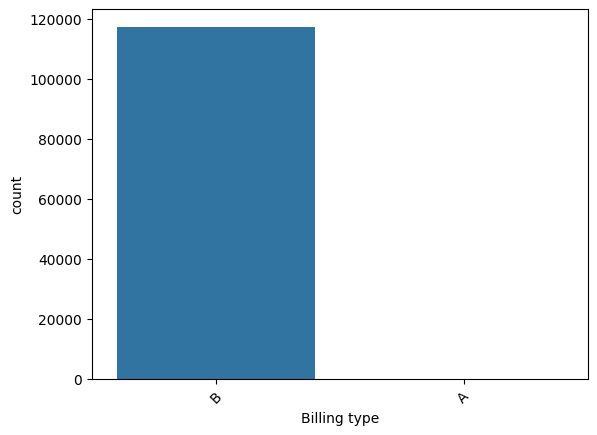

In [309]:
sns.countplot(data=df, x='Fac_Tipo')
plt.xlabel('Billing type')
plt.xticks(rotation=45)
plt.show()

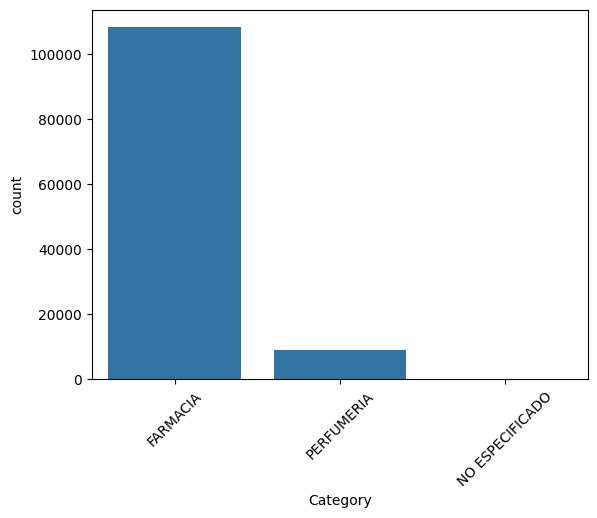

In [310]:
sns.countplot(data=df, x='Rubro')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

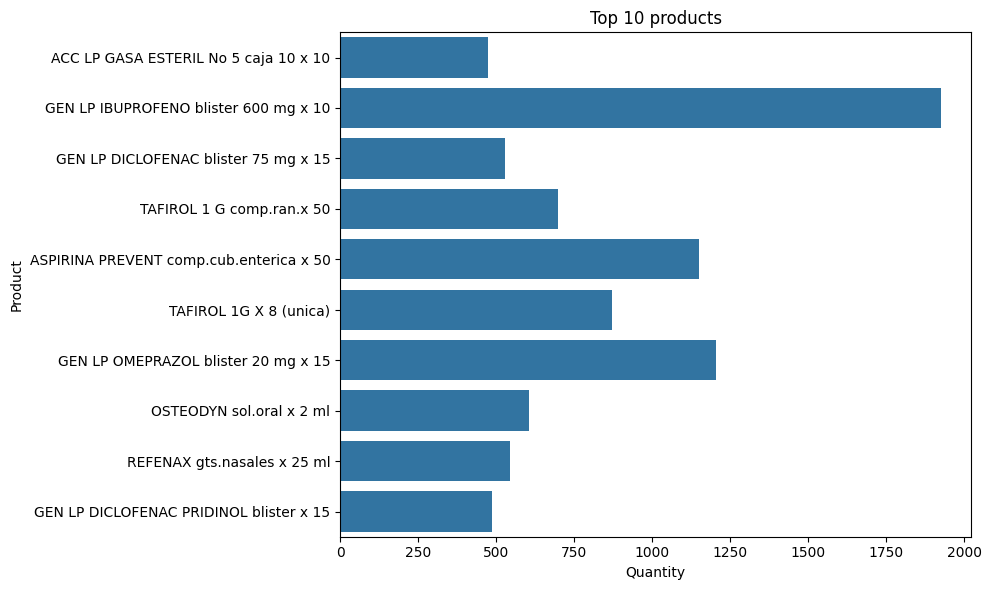

In [311]:
top_products = df['Producto'].value_counts().nlargest(10).index

plt.figure(figsize=(10, 6))
sns.countplot(data=df[df['Producto'].isin(top_products)],
              y='Producto')

plt.title(f'Top 10 products')
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


In [312]:
df['Producto']

0         ACTRON PEDIATRICO 4% susp.oral x 100 ml
1                   AMOXIDAL 500 mg comp.rec.x 21
2                   AMOXIDAL 500 mg comp.rec.x 21
3               MUELITA FORTE GEL gel pomo x 10 g
4                         DIOXAFLEX B12 comp.x 20
                           ...                   
117411                            COLGATE (unica)
117412                  TAFIROL 1 G comp.ran.x 50
117413              CICATRICURE GEL Gel NF x 30 g
117414                  LOUTEN T colirio x 2.5 ml
117415             MADOPAR HBS 125 mg cï¿½ps.x 30
Name: Producto, Length: 117397, dtype: object

In [313]:
df['brand'] = df['Producto'].str.split().str[0]

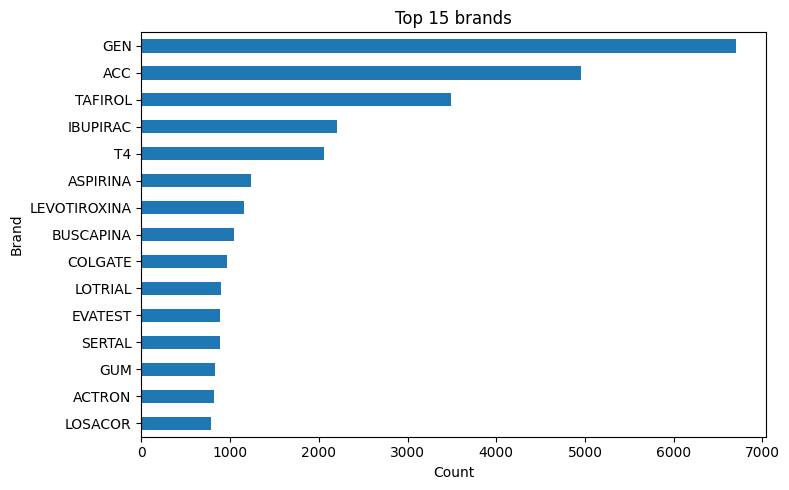

In [314]:
top_brands = df['brand'].value_counts().nlargest(15)

plt.figure(figsize=(8, 5))
top_brands.sort_values().plot(kind='barh')
plt.title('Top 15 brands')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

#### Observación: Inconsistencia en la estructura de nombres de productos
Al analizar el gráfico de "Top 10 Brands", se detecta que el método de extraer la primera palabra (str.split().str[0]) genera datos erróneos por tres razones principales:
- Nombres genéricos vs. marcas: Muchos productos comienzan con el principio activo (ej: LEVOTIROXINA, ASPIRINA, DIFENHIDRAMINA) en lugar de la marca comercial. Esto infla artificialmente el conteo de "marcas" que en realidad son drogas genéricas.
- Marcas compuestas: Marcas como ACC LP, GEN LP o T4 MONTPELLIER se cortan a la mitad, perdiendo su identidad real (quedando solo como ACC, GEN o T4).
- Posición variable de la marca: En algunos registros, la marca no es la primera palabra. Por ejemplo:

    - PROMO DERMAGLOS SOLAR... (La marca es Dermaglós, pero el código toma Promo).   
    - KIT FARMACOLOR... (La marca es Farmacolor, pero toma Kit).   
    - CEPILLO GUM... (La marca es GUM, pero toma Cepillo).   

In [315]:
def pharmacy_products(texto):
    if pd.isna(texto):
        return 'Unknown'
    
    texto = texto.lower()
    
    if 'comp' in texto:
        return 'Comprimido'
    elif 'gel' in texto:
        return 'Gel'
    elif 'susp' in texto:
        return 'Suspensión'
    elif 'colirio' in texto:
        return 'Colirio'
    elif 'jarabe' in texto:
        return 'Jarabe'
    elif 'caps' in texto or 'cáps' in texto:
        return 'Cápsula'
    else:
        return 'Otros'

df['form'] = df['Producto'].apply(pharmacy_products)

In [316]:
df['form'].value_counts()

form
Otros         59373
Comprimido    52989
Gel            1796
Suspensión     1548
Cápsula        1129
Colirio         427
Jarabe          135
Name: count, dtype: int64

In [317]:
df.groupby('Producto')['Precio'].std().sort_values(ascending=False).head(10)

Producto
AREXVY fco.a.liof.x1+disolv.x1                   189958.021297
FLORATIL 250 250 mg cï¿½ps.x 50                   55057.512253
MIRENA dispos.intrauterino x 1                    54804.697517
PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8     51147.274245
EPAMIN cï¿½ps.x 90                                42744.301365
TRAYENTA comp.rec.x 30                            42619.426993
INFANRIX HEXA pvo.liof.+susp.iny.                 41973.461362
ACCU-CHEK PERFORMA 50 tiras reactivas x 50        40802.105626
SHINGRIX liof.vial x 1 + ady. x 1                 38919.707524
MAMADERA (unica)                                  35496.760416
Name: Precio, dtype: float64

#### Problemas detectados:
- PARACETAMOL con desviación de $51,147
- MAMADERA con desviación de $35,496
- AREXVY con desviación de $189,958

In [322]:
df[df['Producto'].str.contains('PARACETAMOL 1 GRAMO', case=False)]['Precio'].describe()

count         4.000000
mean      45057.000000
std       51147.274245
min        1500.000000
25%        1500.000000
50%       39364.000000
75%       82921.000000
max      100000.000000
Name: Precio, dtype: float64

In [ ]:
# To see all the prices of Paracetamol
df[df['Producto'].str.contains('PARACETAMOL 1 GRAMO', case=False, na=False)]

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form
12008,2025-02-04 17:47:12,B,387287,3,1500.0,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,4500.00,FARMACIA,0.0,0.0,4500.00,0.0,0.0,0.0,4500.00,PARACETAMOL,Comprimido
12837,2025-02-06 19:41:19,B,387802,1,1500.0,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,1500.00,FARMACIA,0.0,0.0,1500.00,0.0,0.0,0.0,1500.00,PARACETAMOL,Comprimido
42674,2025-05-05 09:53:16,B,406131,8,77228.0,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,1544.56,FARMACIA,0.0,0.0,1544.56,0.0,0.0,0.0,1544.56,PARACETAMOL,Comprimido
86917,2025-09-22 08:52:00,B,436902,8,100000.0,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,2000.00,FARMACIA,0.0,0.0,2000.00,0.0,0.0,0.0,2000.00,PARACETAMOL,Comprimido


> Ventas totales: 4   
> Precio promedio: $45,057   
> Desviación estándar: $51,147   
> Rango: $1,500 - $100,000   
>
> El precio máximo ($100,000) es 66 veces mayor que el mínimo ($1,500).
> La mediana ($39,364) está muy alejada del mínimo, lo que indica que hay 2 valores normales ($1,500 cada uno) y 2 valores anómalos ($39,364 y $100,000).
> El Paracetamol genérico en Argentina cuesta entre $1,000 y $3,000 por caja. Un precio de $100,000 es imposible.
>
> **Conclusión:**   
> Hay un **error** de tipeo o error de carga.

In [331]:
# To change the outlier (we have the total_cliente and total_sin_gravar which are the total of this raw)
df.loc[42674, 'Precio'] = df.loc[42674, 'Sub_Total']
df.loc[86917, 'Precio'] = df.loc[86917, 'Sub_Total']

In [332]:
df[df['Producto'].str.contains('PARACETAMOL 1 GRAMO', case=False, na=False)]

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form
12008,2025-02-04 17:47:12,B,387287,3,1500.00,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,4500.00,FARMACIA,0.0,0.0,4500.00,0.0,0.0,0.0,4500.00,PARACETAMOL,Comprimido
12837,2025-02-06 19:41:19,B,387802,1,1500.00,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,1500.00,FARMACIA,0.0,0.0,1500.00,0.0,0.0,0.0,1500.00,PARACETAMOL,Comprimido
42674,2025-05-05 09:53:16,B,406131,8,1544.56,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,1544.56,FARMACIA,0.0,0.0,1544.56,0.0,0.0,0.0,1544.56,PARACETAMOL,Comprimido
86917,2025-09-22 08:52:00,B,436902,8,2000.00,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,2000.00,FARMACIA,0.0,0.0,2000.00,0.0,0.0,0.0,2000.00,PARACETAMOL,Comprimido


In [333]:
# To change the quantity because 8 products cannot have this price
df.loc[42674, 'Cant'] = 1
df.loc[86917, 'Cant'] = 1

In [334]:
df[df['Producto'].str.contains('PARACETAMOL 1 GRAMO', case=False, na=False)]

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form
12008,2025-02-04 17:47:12,B,387287,3,1500.00,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,4500.00,FARMACIA,0.0,0.0,4500.00,0.0,0.0,0.0,4500.00,PARACETAMOL,Comprimido
12837,2025-02-06 19:41:19,B,387802,1,1500.00,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,1500.00,FARMACIA,0.0,0.0,1500.00,0.0,0.0,0.0,1500.00,PARACETAMOL,Comprimido
42674,2025-05-05 09:53:16,B,406131,1,1544.56,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,1544.56,FARMACIA,0.0,0.0,1544.56,0.0,0.0,0.0,1544.56,PARACETAMOL,Comprimido
86917,2025-09-22 08:52:00,B,436902,1,2000.00,PARACETAMOL 1 GRAMO 1 g blï¿½st.x 50 comp.x 8,2000.00,FARMACIA,0.0,0.0,2000.00,0.0,0.0,0.0,2000.00,PARACETAMOL,Comprimido


In [335]:
# To see all the prices of Mamadera
df[df['Producto'].str.contains('MAMADERA', case=False)][['Producto', 'Precio', 'Fecha']].sort_values('Precio')

,Producto,Precio,Fecha
23465,MAMADERA 250 ML./ TETINA DE SILICONA,3500.0,2025-03-12 16:25:01
11937,MAMADERA (unica),9000.0,2025-02-04 15:14:06
66727,MAMADERA FC+ 150 ml Control de Temperatura Cor...,22600.0,2025-07-22 18:37:19
23889,SCY 103/01 MAMADERA ANTICOLIC REFRESH 260 ML,28000.0,2025-03-13 18:20:24
101392,SCY 903/67 MAMADERA NATURAL RESPONSE 260ml DEC...,47200.0,2025-11-04 15:03:48
13650,MAMADERA (unica),59200.0,2025-02-10 10:12:24


> **Conclusión:**   
> No es un error, están agrupandas mamaderas básicas ($3,500) con mamaderas premium de tecnología avanzada ($47,200).

In [336]:
# To see all the prices of Arexvy
df[df['Producto'].str.contains('AREXVY', case=False)][['Fecha', 'Precio', 'Cobertura', 'Total_Cliente']].sort_values('Precio')

,Fecha,Precio,Cobertura,Total_Cliente
73104,2025-08-09 19:16:27,29000.00,0.000,29000.000
66276,2025-07-21 18:10:58,297641.21,119056.484,178584.726


> **Observaciones:**
>
> Al revisar los datos de AREXVY, se detecta una inconsistencia grave: una de las entradas registra un precio de lista de $29,000 con $0 de cobertura, mientras que la otra registra $297,641. Dado que el valor de mercado de esta vacuna es cercano a los $300,000, la entrada de $29,000 debe considerarse un error de registro o un dato incompleto, ya que no representa el valor real del bien ni existe una cobertura que justifique la diferencia.

In [337]:
df.groupby('form')['Desc_Adic'].mean()

form
Colirio        24.382265
Comprimido     13.214385
Cápsula        21.956524
Gel           204.311876
Jarabe          0.000000
Otros         132.925216
Suspensión     -4.164778
Name: Desc_Adic, dtype: float64

In [338]:
df['product_name'] = (df['Producto']
                       .str.lower()
                       .str.replace(r"[^a-z0-9 ]", "", regex=True))

In [339]:
df['product_name'].value_counts().head(30)

product_name
gen lp ibuprofeno blister 600 mg x 10                       1926
gen lp omeprazol blister 20 mg x 15                         1205
aspirina prevent compcubenterica x 50                       1150
tafirol 1g x 8 unica                                         870
tafirol 1 g compranx 50                                      699
osteodyn soloral x 2 ml                                      605
refenax gtsnasales x 25 ml                                   543
gen lp diclofenac blister 75 mg x 15                         530
gen lp diclofenac pridinol blister x 15                      488
acc lp gasa esteril no 5 caja 10 x 10                        473
corbis 5 mg comprecx 30                                      471
tafirol plus rapida accion cpsbl x 8                         471
alikal unica                                                 451
t4 montpellier 75 75 mcg compx 50                            446
acc lp tela antialergica 3m de 25 x 9 sracionador microp     438
t4 montpelli

In [340]:
df['Producto'].nunique()

7667

In [341]:
df['Producto'].dropna().drop_duplicates().sort_values().head(100)

88134      CHUP.MANZANITA(C/DIBUJO)T/SILIC.+3M RED - ES...
34267                                              (unica)
45585                        102 ANOS PLUS ANTIOXIDANTE 30
987                         102 ANOS SPORT MAX 30 SOBRES /
71061                       102 MAGNESIO CITRATO 30 COMP S
                               ...                        
104      ACC LP TELA ANTIALERGICA 3M de 2.5 x 9 S/Racio...
41094    ACC LP TELA ANTIALERGICA 3M de 5 x 9 C/Raciona...
76       ACC LP TELA ANTIALERGICA 3M de 5 x 9 S/Raciona...
224      ACC LP TELA ANTIALERGICA 3M de1.25 x 9 S/Racio...
3460     ACC LP TELA ANTIALERGICA 5 x 9 S/Racionador Mi...
Name: Producto, Length: 100, dtype: object

In [342]:
pharmaceutical_classifier = {
    'Salud Cardiovascular': ['alpertan', 'sartan', 'pril', 'olol', 'dipino', 'estatina', 'lipitor', 'lipokemia',
        'aspirina prevent', 'valsarfec', 'tervalon', 'ateronova', 'blokium', 'befol', 'furosemida', 'lipomax', 'combinater',
        'torivas', 'aspirinetas', 'racorval', 'atenolol', 'enalapril', 'amlodipina', 'rovartal', 'mecanyl', 'paraclim', 'oldren', 'lercadip',
        'losartan', 'amloc', 'cardio', 'aldactone', 'lotrial', 'simultan', 'arteriosan', 'nebicor', 'sarmec', 'lonikan', 'infiltrex', 'tetrazic',
        'diurex', 'rosustatin', 'rovastane', 'epistal', 'minuslip', 'regulip', 'medocor', 'bisofec', 'nebilet', 'tensimed',
        'carrier', 'meplar', 'losacor', 'prinil', 'lipifen', 'dilcoran', 'acalix', 'rosufen', 'syncrocor', 'letondal',
        'ateroclar', 'aturen', 'daunlip', 'espironol', 'filten', 'pelmec', 'rosufec', 'aclusin', 'tacicul', 'edagan',
        'bilip', 'bertel', 'nabila', 'corbis', 'diapresan', 'ixium', 'azecar', 'veraten', 'clopidogrel', 'astende',
        'acalik', 'atenix', 'indalten', 'glioten', 'diocam', 'meridian', 'dipemina', 'valpex', 'loctenk', 'zarator', 'loplac',
        'ilduc', 'bisopil', 'prisonil', 'sinlip', 'blavin', 'nivas', 'ultrex', 'vasotenal', 'antipresol', 'minicam', 'lasix',
        'sarval', 'atorvastatin', 'lostam', 'peptazol', 'vastarel', 'coracil', 'euretico', 'antiplaq', 'drimux',
        'ixacor', 'rosuvast', 'sistatin', 'tacardia', 'tanavat', 'renitec', 'crestor', 'flebosmina', 'enatral', 'pixaban',
        'montrate', 'corpres', 'endial', 'explaner', 'diural', 'pgb 75', 'diovan', 'togrel', 'clarimax', 'acantex',
        'aceno', 'acenocoumarol', 'alental', 'alipas', 'amix', 'amlodicord', 'amlodisane', 'amlopaw', 'aplacasse', 'aterva',
        'atucha', 'belozok', 'bempezet', 'benlipid', 'biascor', 'bicardil', 'bisofec', 'candesartan', 'cardionorm', 'cardiorex', 'carflax',
        'carvedil', 'carvedilol', 'cilos', 'cilostal', 'cilostazol', 'clodrel', 'clopilep', 'corosan', 'coroval', 'coverene', 'cozaarex', 'cristaclar',
        'oldinot', 'reovex', 'cvp flebo', 'drinax', 'atlansil', 'zocor', 'lipex', 'incoril', 'natrilix', 'irazem', 'rolast', 'plenacor', 'lopid', 'procardia', 
        'diondel', 'rostazina', 'policor', 'presimax', 'micardis', 'atorvastan', 'rosuber', 'tritab', 'tonibral', 'toltem', 'delak', 'pleyar', 'dilatrend', 'desaler', 
        'noster', 'sintrom', 'atarva', 'nifed sol', 'terloc', 'vytorin', 'rospower36', 'exforge', 'kemoter', 'pravil duncan', 'exforge', 
        'lonikan', 'infiltrex', 'tetrazic', 'lisaler', 'periplum', 'pivast', 'nodis', 'tencas', 'plidex', 'pravil duncan', 'exforge', 'verboril', 'zundic',
        'rentop', 'blastop', 'eplerona', 'nonlipid', 'novurit', 'gadocor', 'lagotran', 'etacril', 'sinaler', 'lebocar', 'evoquin',
        'vigicer', 'circuvit', 'recupel', 'sotacor', 'fenofibrato micronizado richet', 'rosucol', 'atacand', 'lunel 75 practidosis',
        'ristonel', 'vorst', 'craveril', 'hiperval', 'odranal', 'plidan', 'ezetrol', 'rociamin', 'vastina', 'firialta',
        'bigetric', 'duerix', 'nirpol', 'tritace', 'denverkast', 'treg', 'joker flex', 'finlipol', 'biorgan'],
    
    'Salud Mental / Sistema Nervioso': ['pisono', 'alplax', 'alprazolam', 'clonazepam', 'diazepam', 'fanter', 'lanx', 'equilibrane', 'remeron', 'topictal',
        'sertralina', 'fluoxetina', 'lexapro', 'psicoasten', 'quetiapina', 'somit', 'clonagin', 'trapax', 'noches', 'lucidex', 'eumotil',
        'lamotrigina', 'zepam', 'latrigin', 'paxon', 'risperin', 'novo', 'asertral', 'ivestron', 'madopar', 'taxagon ad', 'lamocas', 'meleril', 'dormiro',
        'psicotil', 'rivotril', 'tiarix', 'ampliar', 'ultraneural', 'migral', 'clonagin', 'trastocir', 'duxetin', 'trastocir', 'rostrum',
        'gavin', 'insertec', 'lextor', 'lexotanil', 'tranquinal', 'comenter', 'remizeral', 'aropax', 'quetiazic', 'discretal', 'quetiaros',
        'neuryl', 'emotival', 'serubel', 'valium', 'carbamazepina', 'memantina', 'zoloft', 'depakene', 'elafax', 'neuristan', 'cabal',
        'inductal', 'epamin', 'mestinon', 'melatol', 'armonil', 'modaton', 'climatix', 'audax', 'anafranil', 'tegretol', 'merital', 'sesaren',
        'actinerval', 'actison', 'akineton', 'alzepral', 'amiptril', 'ampk', 'anafranil', 'anelka', 'atemperator', 'biatrix', 'biperideno',
        'brintellix', 'ceglution', 'clonadane', 'clonax', 'conexine', 'conformal', 'consiv', 'continex', 'cuait', 'humorap', 'meleril', 'dormi-ros',
        'seroquel', 'neutop', 'deslafax', 'nocte', 'alprazol', 'afenexil', 'tueris', 'dominium', 'circonyl', 'lyrica', 'talpram', 'kanbis', 'optiser',
        'petrium', 'zentius', 'tryptanol', 'rediun', 'lamirax', 'audipax', 'ataraxone', 'paxil', 'donepes', 'mystika', 'rohypnol', 'pristiq', 'meibi',
        'valcote', 'dacten', 'lamictal', 'meprozin', 'etiasel', 'moperidona af', 'revertrix', 'aurene', 'rabloc', 'nitrodom', 'hipolipol',
        'neurontin', 'zenelis mareos', 'midax', 'xanax', 'zolodorm', 'lioresal', 'inquetia', 'rostalopram', 'valeriana', 'segren', 'kabian 100', 'equitone'],

    'Salud Digestiva': ['alumpak', 'alverin', 'almax', 'omeprazol', 'pantoprazol', 'reflux', 'dulcolax', 'gastromax', 'rogastril', 'miopropan', 'genoprazol', 'barex',
        'lanzoprazol', 'aci-tip', 'agarol', 'buscapina', 'bagohepat', 'lactulon', 'sinulcus', 'peptazol', 'esoprazol', 'deblax', 'anusol',
        'chofitol', 'bismuto', 'oligoplex', 'mylanta', 'taural', 'bicarbonato', 'qg5', 'sincerum', 'mudantil', 'reliveran', 'pantus', 'pantus',
        'alikal', 'sertal', 'regulane', 'axiomat', 'loperamida', 'ulcozol', 'lactulon', 'mutum', 'zoltenk', 'mebutar', 'remexal',
        'suerox', 'vorpix', 'aziatop', 'uvasal', 'rennie', 'hepatalgina', 'aglucide', 'acimed', 'esomepra', 'dexopral', 'antihemorroidal', 'prune iii', 'subical',
        'biletan', 'agiolax', 'reliveran', 'malvahp', 'genoprazol', 'gastromax', 'enterogermina', 'sucralfato', 'lorebil', 'dulcolax', 'actual comp', 'gastec',
        'aci-tip', 'acimed', 'agarol', 'agiolax', 'alverin', 'ansielix', 'apasmo', 'barex', 'carbogasol', 'carbon', 'cascara', 'ciruela', 'ciruelax', 'creon',
        'pantocas', 'eudon', 'paratropina', 'rempec', 'panastat', 'xilocler', 'fosfalax', 'ricino', 'bil', 'dramamine', 'lemil pvo', 'laxamin',
        'nikzon', 'urdecole', 'ilotcina', 'pantop', 'enemol', 'floratil', 'carmin', 'ilotcina', 'actual bl', 'plenica', 'desaler', 'lanzopral',
        'proctyl', 'spasmoctyl', 'laragon', 'iloticina', 'fosfo', 'diaris', 'nexium', 'sarmec', 'esodar', 'mosar', 'procto-ikatral', 'vermicet', 'pentasa', 'procto',
        'diar', 'vedipal', 'omecap', 'medilaxan', 'vecetam', 'nastizol', 'ultraprazol', 'lopecian', 'digecaps', 'molagar'],

    'Salud Sexual / Urología': ['nafil', 'dalafil', 'sildenafil', 'tadalafil', 'vimax', 'lubricante', 'invictus'],

    'Oftalmología': ['alphagan', 'ofta', 'colirio', 'timolol', 'latanoprost', 'lágrimas', 'idena', 'latlas', 'coltix', 'isis', 'flarex', 'latano',
        'gotas', 'tobrex', 'gatidex', 'soloftlmica', 'tobradex', 'sensu', 'natax', 'fotamicin', 'arlyt', 'plostim', 'flarex', 'tansiloprost',
        'restasis', 'systane', 'aucic', 'irix', 'opti free', 'gota pc', 'timed', 'quidex', 'coltix', 'latlas', 'gotabiotic', 'gtsoftx', 'lagrima',
        'acrylarm', 'alcon', 'alosol', 'arlyt', 'artelac', 'aucic', 'azarga', 'azopt', 'berlofen', 'bideon', 'eyes', 'brimopress', 'brit', 'brixia', 'cipos', 'closporil', 'coltix',
        'lagrimas', 'lagrima dorf', 'osiris sol', 'olopat', 'inmunosporin', 'glaucotensil', 'tears', 'tolf emuls', 'mirus sol', 'proflax', 'travatan',
        'ketif solx', 'glaucoprost', 'patanol', 'latanoflax', 'ocurel lc sol', 'ketif', 'newclar', 'isoptomax', 'ketif sol', 'isoptomax', 'tralerc lc',
        'fotadex', 'rifamicyn', 'tacines', 'dorlamida', 'lubrol', 'xalatan'],

    'Antibióticos': ['cilina', 'micina', 'floxacino', 'cicli', 'cef', 'amoxi', 'poviral', 'leflumax', 'nixoran', 'ivercass',
        'clavulanico', 'ceporexin', 'triamid', 'debril', 'nabratin', 'macril', 'bactrim', 'misultina', 'furadantina mc', 'dalacin c',
        'poviral', 'bactifren', 'leflumax', 'nixoran', 'azibiotic', 'flagyl', 'cronopen', 'dalacin c', 'urofuran', 'keforal',
        'acantex', 'acifusin', 'amikacina', 'amixen', 'amoclav', 'amoxicilina', 'amoxidal', 'amoxol', 'arotran', 'nexpeci', 'silfab pix',
        'asolmicina', 'avelox', 'azibiotic', 'azitromicina', 'azitrox', 'bactifren', 'bactrim', 'bioclavid', 'biotic', 'cefacar', 'cefalexina', 'cetaxim', 'ciriax',
        'claribiotic', 'clarimax', 'claritrom', 'claritromicina', 'clarovil', 'clavulox', 'clidan', 'clindacin', 'clindacur', 'clindamicina', 
        'xiclovir', 'pen di ben', 'nitrofurazona', 'estreptocarbocaftiazol', 'lisovyr', 'oralsone', 'metronidazol', 'nistatina',
        'nexpecil', 'rifadom', 'macromax'],

    'Antimicóticos': ['fluconazol', 'fangan', 'terekol', 'fungueal', 'micoral', 'itrac', 'terbenol duo', 'flupec', 'medifungol',
                      'perfungol', 'fungo nail', 'micotral', 'mycanden', 'ivertal'],

    'Analgésicos / Antiinflamatorios': ['profeno', 'fenaco', 'coxib', 'paracetamol', 'aspirina', 'fungocina', 'unesia', 'dorixina', 'mafel 200', 'diclo',
        'dol', 'clonixinato', 'mejoral', 'geniol', 'meloxicam', 'muelita', 'fabogesic', 'actron', 'next', 'tetralgin', 'sinalgico',
        'dioxaflex', 'ketorolac', 'tafirol', 'naprux', 'diclofenac', 'artrosil', 'anaflex', 'procetoken', 'liparex', 'gargaletas', 'serrapep',
        'prontal', 'ibu', 'evanol', 'diclomar', 'flogocox', 'bengue', 'ponstil', 'tetralgin', 'sinalgico', 'desinflamante', 'ernex', 'tryptalgin',
        'acloxigenac', 'actron', 'algicur', 'algispray', 'alikal', 'anaflex', 'arcoxia', 'arnica', 'artrosil', 'artrostop', 'aspirina', 'aspirinetas',
        'atomo', 'bayaspirina', 'befol', 'bengue', 'blokium', 'calmador', 'contractil', 'enantyum', 'migratriptan', 'predual', 'flexina', 'rodinac flex',
        'naprontag', 'rodinac', 'xumer', 'naprontag', 'diclogesic', 'naprontag', 'falgos', 'im 75 montpellier', 'fluticort', 'flumetol', 'lopred', 'otex hc',
        'otosporin', 'tetralg', 'talgiax', 'supracam', 'tetralg', 'talgiax', 'paravetamol', 'novalgina', 'ultragesic cb', 'flexresan'],

    'Salud Respiratoria / Antialérgicos': ['tadina', 'rizina', 'nasona', 'terol', 'ambroxol', 'mucol', 'frevia', 'alernix', 'aerotina', 
                                           'alercas', 'acemuk', 'aerius', 'frenadol', 'antigripal', 'ventolin', 'athos', 'relvar', 'neumocort', 
                                           'nasal', 'lukast', 'aliviatos', 'caramelos', 'refrianex', 'salbutamol', 'otoclean', 'novacler', 'pulmosan',
        'asmavitan', 'seretide', 'refenax', 'lidil', 'cedric', 'flutivent', 'collubiazol', 'pulmocler', 'salbutral', 'cetizine', 'refrianex', 'proetzonide',
        'acemuk', 'aerius', 'aerogal', 'aerolep', 'aerotina', 'aerotrop', 'aerovent', 'aeroxina', 'aireal', 'alergitrat', 'alermina', 'alerpriv', 'alertial',
        'aliviatos', 'anoro', 'aseptobron', 'asmabron', 'asmavitan', 'atrophen', 'atrovent', 'benadryl', 'bisolhelix', 'bisolvon', 'bronax', 'bronquisedan', 
        'bronsol', 'bucoangin', 'bucogel', 'bucotricin', 'budesonida', 'butocort', 'cedrimuc', 'cetriler', 'flixotide', 'kanbis sol oral', 'allegra', 'neumotide',
        'neumotex', 'filotricin', 'supraler', 'salbuden', 'lisi', 'symbicort', 'lafedryl', 'febratic', 'termofren', 'acc expectorante', 'incruse ellipta',
        'fluticort', 'flumetol', 'lopred', 'otex hc', 'neumotropio', 'aliviapres', 'decidex grip', 'resaquit', 'levomine', 'spiriva', 'decidex', 'proair bronquial',
        'expectosan antitusivo', 'febrigrip', 'ismigen', 'octanyl', 'rino-b nebu', 'tukol ac', 'tukol miel y tomillo', 'pulmonix grip','tukol buc miel',
        'kipergrip', 'plenair'],

    'Antialérgicos': ['dexalergin', 'hexaler', 'frenaler', 'difenhidramina', 'cortipyren'],

    'Higiene y Cuidado Personal': ['shampoo', 'acondicionador', 'jabon', 'desodorante', 'axe', 'st ives', 'fluordent', 'plac out', 'dentilac', 'evagina', 'trim', 'gel',
        'dove', 'colgate', 'pasta dental', 'cepillo', 'hilo dental', 'gillette', 'listerine', 'venus', 'tuly',
        'enjuague bucal', 'protector', 'neutrogena', 'dermaglos', 'ensure', 'nopucid', 'sapolan', 'lux botan jazmin',
        'aderma', 'aveno', 'cerave', 'vichy', 'la roche', 'cicatricure', 'OB', 'issue', 'malva',
        'lactacyd', 'asepxia', 'biferdil', 'capilatis', 'cutex', 'idi', 'medicasp', 'ortodoncia',
        'siempre libre', 'always', 'carefree', 'softpicks', 'rexona', 'cepillo', 'glicerina', 'millefiori microondas',
        'close', 'proxa', 'johnson', 'carey', 'pantene', 'nivea', 'hinds', 'tresemmé', 'esmalte',
        'labello', 'clear', 'corega', 'flossers', 'discos', 'farmacolor', 'esmalte', 'cortauas',
        'dermagls', 'eumicel', 'libre', 'listerine', 'gum', 'tresemme', 'veet', 'ciel', 'difusor', 'cisne beauty', 'mas cisne color',
        'escofina', 'eva gina', 'toallitas', 'sensodyne', 'piroctol', 'desodorante', 'algodón', 'veritas',
        'dermagls', 'nosotras', 'kevin black', 'kevin absolute', 'kevin park', 'kevin ice', 'mujercitas', 'agua de azahar',
        'tio nacho', 'manteca', 'borato', 'squam', 'kritel', 'inecto', 'orde', 'foot', 'solar', 'oral b', 'azucena',
        'acneique', 'acnesan', 'acnetrol', 'acnoxin', 'acondicionador', 'aderma', 'adermicina', 'aloebel', 'alumpak', 'atrix', 'avene', 'avixis', 'bagovit',
        'batiste', 'biokeratin', 'blefaskin', 'brown', 'bucaltac', 'buchex', 'bushi', 'butler', 'caladryl', 'capilex', 'capillaire', 'cetaphil',
        'cleanex', 'clear', 'men', 'clericot', 'cocot', 'colonia', 'cutex', 'preal', 'dentilac', 'depilmiel', 'depilorm', 'depimiel', 'deralbine', 'dercolina',
        'derm', 'dermacler', 'dermadex', 'dermaglos', 'especial', 'lima', 'old spice', 'goicoechea', 'elite disney pocket',
        'acf by dadatina', 'ponds', 'dots frutos', 'plenitud', 'lux unica', 'fulton (unica)', 'gillete sensitive',
        'mordillo extra refrigerante', 'natura express', 'acc lp pasta lasar', 'adult care', 'bromhistop',
        'off (unica)', 'zalea', 'colitas (unica)', 'crema (unica)', 'feen a mint', 'eucerin aquaphor', 'peine unica', 'colitas', 
        'dots frutillas', 'off extra duracion', 'unifresh limpiador', 'labial unica', 'evo unica', 'skyn unica', 'azucen'
        'esfumel', 'noc 10 concentrada', 'tena discreet', 'foto ultra age repair', 'esfumel blanqueadora', 'uelos (unica)',
        'lux (unica)', 'lidclean', 'off defe', 'esponja', 'feen a mint', 'garnier agua mic', 'tulipan super finos', 
        'piedra pomez', 'tena pants', 'PA�O', 'impulse musk', 'yeruti torta', 'tulipan', 'skyn', 'emal diaman', 'pañuelos', 'pañuelitos',
        'lubrol clean', 'emoform', 'pao unica', 'heno de pravia', 'colita', 'nail (unica)', 'labial (unica)', 'evo (unica)',
        'satin (unica)', 'talquera', 'talco veritas', 'oral b (unica)', 'ozono (unica)', 'SKIM', 'umasam jab', 'elite',
        'pañuelos', 'talco', 'lux botan orq negra', 'off family crema', 'greta', 'sen', 'labial mate', 'labial larga duracion', 
        'coronet metali', 'oral b unica', 'mas broch', 'lux botan orq negra', 'off family crema', 'greta', 'sen', 'labial mate', 'labial larga duracion', 
        'lux botan france rep', 'mascara', 'esmalt (unica)', 'lux botan lirio azul', 'paula luz', 'tortulan desmaq bifasico', 'loreal base', 'maybelline fire work',
        'garnier skin act bifa agua mic', 'solvente', 'delineado lapiz', 'tulioan', 'lapiz corrector'],

    'Accesorios y Dispositivos Médicos': ['pañal', 'huggies', 'pampers', 'toalla', 'algodon', 'jeringa', 'collar', 'espejo',
        'aguja', 'preservativo', 'condon', 'test', 'termometro', 'soft', 'comodin', 'inconti', 'latex', 'omron automat', 'fashion (unica)',
        'curitas', 'accesorio', 'barbijo', 'maxx', 'broche', 'espermicida', 'prime', 'franklin', 'pastillero', 'toma presion',
        'almohada', 'almohadilla', 'arquador', 'aspirador', 'assy', 'atucha', 'innovation', 'bajalenguas', 'pinza (unica)',
        'barbajo', 'barbijo', 'bisturi', 'bolsa', 'botiquin', 'broche', 'cepillo', 'chata', 'cinta', 'colector', 'comodin', 
        'contour', 'cortapastilla', 'cortaunas', 'cotonetes', 'curita', 'dedal', 'dedo', 'delineador', 'pastillero', 'gorro ducha',
        'accesorio', 'textil', 'faja', 'peine', 'alicate', 'tijera', 'accesesorios', 'maverick digital', 'pera unica', 'bandaid', 'procer',
        'pera', 'traspore', 'organizador', 'mas pinza', 'vinchas', 'sol fis', 'estuche', 'vortex aerocamara', 'pulsera', 'brazalete'],

    'Nutrición y Suplementos': ['magnesio', 'vitamina', 'suplemento', 'ensure', 'pediasure', 'linus', 'control k',
        'bagovit', 'centrum', 'berocca', 'supradyn', 'acifol', 'hierro', 'nutrilon', 'ostelin', 'vitalix', 'crafine', 'magnal',
        'calcio', 'soloral', 'osteodyn', 'omega', 'chia', 'colageno', 'tapones', 'dbi', 'tanvimil', 'ajo', 'kaon elixir', 'fer in sol',
        'artrostop', 'curflex', 'b12', 'becozym', 'redoxon', 'bernafolic', 'glucerna', 'magnesiano', 'capskrill', 'estrella', 'lactibon', 'merital',
        'devisal', 'sterogyl', 'raquiferol', 'oravil', 'larotabe', 'quelat', 'siderblut', 'gadoferol', 'valcatil', 'allopurinol',
        '102', 'mujer', 'plus', 'sport', 'acifol', 'aminoterapia', 'anemidox', 'anfolic', 'arandano', 'arginina', 'azidac', 'b1', 'b6',
        'b12', 'bago+', 'berocca', 'bisglicinato', 'blue-vit', 'blueking', 'fort', 'cal', 'vita', 'calcimax', 'calcio', 'calciocit', 'calcional', 'calcitriol', 
        'cartilago', 'centrum', 'chia', 'chiacaps', 'ciagen', 'oil', 'colageno', 'curcuma', 'food', 'chuker', 'espesan', 'egestan folico',
        'vientre plano', 'trip d3', 'exertial', 'citrato de maganesio', 'maternil', 'framintrol', 'satial carb controller',
        'ferinjec', 'kaon elixir', 'natuliv', 'piedra china', 'resveratrol francelab', 'colmibe', 'gen lp carb', 'metabolic cla', 'priotic',
        'iu 400', 'ferrologic', 'cados', 'ferinject', 'de india', 'spirulina', 'garcinia', 'venofer', 'cuasia amarga', 'metabolic max', 'generday equilibrio',
        'i.u. 400', 'sacarina', 'ultraflex', 'ferive', 'pharmaton essential', 'sucaryl', 'caramelo (unica)', 'tri vi sol'],

    'Diabetes y Endocrino': ['metformina', 'insulina', 'glibenclamida', 'levotiroxina', 'glucophage', 'danantizol', 'nexdia',
        't4', 'glucosa', 'glucogood', 'forxiga', 'islotin', 'diamicron', 'aglucide', 'siaglix', 'zomarist', 'imecot', 'glemaz',
        'aglucide', 'agliptin', 'azatioprina', 'dagliben', 'dbi', 'glifosin', 'trayenta', 'januvia', 'enclyna', 'glidanil', 'neurotioct',
        'accu','diabo', 'diabesil ap', 'accuchek guide tiras reactivas', 'metglucon', 'diabesil', 'victoza', 'dapax', 'jardiance', 'euglucon'],

    'Material de Curación': ['guante', 'gasa', 'iruxol', 'iodopovidona', 'estéril', 'envase', 'curita', 'venda', 'aplicacion', 'curita', 'venda', 'aplicacion',
        'antialérgica', 'tela', 'merthiolate', 'anestésico', 'ox', 'fisiológica', 'alibour', 'fisiologica', 'hipoalergic', 'curita', 'tubos',
        'apositos', 'transpore', 'bandaid', 'aposito', 'band-aid', 'band aid', 'alcohol'],

    'Gripe': ['qura', 'rhinal', 'ventonil'],

    'Dermatología': ['paldar', 'megacistin', 'deralbine', 'vaselina', 'empecid', 'mupax', 'keratopic', 'louten', 'erisol', 'sinamida', 'klomadex',
        'cremtotal', 'hipoglos', 'diabet', 'betacort', 'factor', 'platsul', 'perpiel', 'piecidex', 'dermexane', 'caladryl', 'salil', 'teatrical',
        'dermagls', 'dermagls', 'dermexane', 'caladryl', 'gentaderm', 'filtres', 'fenosane', 'procetoken','dermagls solar', 'vitacortil', 'verruclean',
        'acneclin', 'verrutopic', 'flebosmina', 'abralux', 'acler', 'acneique', 'acnesan', 'acnetrol', 'acnoxin', 'adapne', 'adermicina', 'algicler', 'aristaloe', 
        'arzimol', 'asepxia', 'atopix', 'aurea', 'avixis', 'bacticort', 'bengue', 'benzihex', 'bepanthol', 'betacort', 'betasalic', 'betnovate', 'betriol', 
        'cicanol', 'cicatricure', 'clevosan', 'clidan', 'clindacin', 'clindacur', 'clobesol', 'contractil', 'oremañe', 'cuta', 'cutanit', 
        'denvercrem', 'dercolina', 'derma', 'dermadex', 'dermaglos', 'microsona', 'hifamonil', 'farm', 'salac', 'micolis', 'fitonal', 'micosep',
        'actual compmastx', 'finescar spray', 'metral', 'cicaplast', 'isdin', 'tetralysal', 'mometax', 'serocutin', 'tresite', 'xegrex',
        'soolantra', 'fripi', 'grisovin', 'gentaso', 'pitiriax', 'prurisedan', 'ivercrem', 'fripi flash', 'lupan', 'fusimed b', 'verrugol',
        'securo', 'tacrotic', 'acc lp azufre', 'salicor', 'fusimed', 'pasta al agua', 'hexa defital', 'miquimod', 'tacro-tic', 'alfacort',
        'neotretin m', 'diprogenta', 'masivol', 'licend', 'espuma (unica)', 'lrp mela b3', 'acerpes', 'diabecler', 'efitum', 'miklogen', 'isotan', 'lacorene'],

    'Ginecológico / Salud Femenina': ['fucsia', 'diva', 'colpofilin', 'vagisil', 'ovufem', 'elektra', 'umma', 'levogest', 'isis free', 'yaz', 'kala', 'ginkan', 'vagilen',
                                      'damsella', 'norgestrel', 'divina', 'cerazette', 'amapoli', 'miranda', 'nor', 'fenogynol', 'camelia', 'kali', 'ovata',
                                      'gadofem', 'torgyn', 'colpoestriol', 'femiden', 'damsel', 'slinda', 'ginelea', 'ob', 'diane', 'isis', 'micoclin', 'tricofin',
                                      'ronfase', 'kir', 'ovulos', 'doncella', 'lactamax', 'rubi', 'secret', 'jade', 'aleli', 'yasmin', 'ovumix', 'evacare',
                                      'femexin', 'evra parches', 'mirena', 'ciclocur', 'desire', 'zinnia', 'plan', 'ginal cent', 'prebien', 'metrergina', 'florence',
                                      'zinnia', 'plan', 'ginal cent', 'colpotrophine', 'viasek', 'genozym', 'qlaira', 'microvlar', 'nulipar',
                                      'eucerin intim protect', 'lomeca', 'gino deo', 'tabcin compuesto', 'nulipar', 'cuidafe', 'crada', 'ovulol ud',
                                      'progest', 'promeclim', 'honguil', 'femalvi', 'miranova', 'mesigyna', 'colpoestriene', 'femterona', 'fungototal gyno'],

    'Fragancia': ['cuore', 'pepas', 'paco', 'colbert', 'pink', 'kevin', 'mujercitas', 'edt', 'edp', 'colonia', 'vapo', 'boos', 'herrera', 'perfumeria',
                  'perfumina', 'prune moi', 'kerzen perfu', 'prune i aero', 'paula alegria', 'paula alma', 'impulse true love', 'perfume'],

    'Vascular': ['daflon', 'aliviafleb', 'diosmin', 'reagin vascular', 'reagin', 'venart', 'flevomax', 'varisedan', 'cyclo 3'],

    'Urología': ['reduprost', 'urocont', 'prostoklar', 'duodart', 'sulos', 'magnus', 'urifex', 'finasterin', 'uralos', 'minocass', 'avodart', 'dutapil',
                 'omnic', 'ditropan', 'tarusol', 'permicaps', 'darisec', 'andrin', 'urosedac', 'ursomax', 'cistalgina', 'urokit', 'aclosan', 'triurol', 'dutaklar',
                 'denverprost', 'dutasinar', 'uroseptal', 'ludasterin', 'urginol', 'colpuril a retard'],

    'Otorrino': ['meniex', 'otosan', 'betahistina'],

    'Reumatología': ['brek', 'marvil', 'asotrex', 'ibandronato', 'artrait', 'polirreumin', 'colchicina houde', 'femorel', 'derrumal', 'prolia',
                     'oseum', 'artrodar', 'ribastamin'],

    'Corticoides': ['deltisona', 'corticas', 'cronocorteroid', 'decadron', 'corteroid', 'metilpres', 'duo decadron', 'corteroid retard', 'dexa',
                    'dexatotal', 'celestone', 'suavicort', 'hidrotisona', 'meprednisona', 'demacort', 'hidrotisona', 'deltacort'],

    'Cuidado Capilar:': ['shampoo', 'acondicionador', 'biferdil', 'capilatis', 'inecto', 'nacho', 'pantene', 'tresemme', 'folcres', 'panten', 'sedal liso perfecto', 
                         'elvive ha pure', 'micoral sham', 'garnier vit c', 'anagen', 'elvive oleo', 'propecia', 'lord cheseline', 'matizador', 'sorsis shampx',
                         'salpad t shamp', 'sedal ceramidas', 'tres emme', 'sorsis shamp', 'head shoul', 'sedal co-creations', 'nic re viviendo',
                         'quadion', 'elvive glycolic gloss', 'elvive hidra hialuronico', 'sedal', 'sedal luminoso uv', 'head sho limpieza ac argan',
                         'head  sho'],

    'Cuidado Bucal:': ['colgate', 'sensodyne', 'bucaltac', 'enjuague', 'dental', 'corega', 'odor control', 'elmex', 'plax zero', 'sea bond'],

    'Protección Solar': ['solar', 'fps', 'autobronceante', 'post', 'ozono f50', 'fotosol', 'rayito', 'eryfotona akn', 'spf', 'fusion water', 'eryfotona ak', 
                         'eucerin f50 hydro fluido', 'solenil lips protect', 'loreal uv'],

    'Vacunas y Biológicos': ['qdenga', 'bexsero', 'shingrix', 'infanrix', 'pneumovax', 'vacuna antitetanica', 'vacuna', 'influvac tetra', 'flucelvax quad',
                             'istivac 4'],

    'Endocrino': ['t3 montpellier'],

    'Bebés y Maternidad': ['nan sin lactosa', 'mamadera', 'termokids', 'chupete', 'chup', 'vaso aprendizaje', 'petit enfant bebe', 'pañales', 'sancor bebe',
                           'ig fit extra absorbente', 'scf 551/05 vaso easy sip', 'tetinas'],
}

In [344]:
with open('pharmaceutical_classifier.json', 'w', encoding='utf-8') as f:
    json.dump(pharmaceutical_classifier, f, ensure_ascii=False, indent=2)

In [345]:
def assign_category(name):
    name = str(name).lower()
    for category, names in pharmaceutical_classifier.items():
        for word in names:
            if word in name:
                    return category
    return 'Otros'

df['groups'] = df['Producto'].apply(assign_category)

In [346]:
mask = df['groups'].isin(['Otros', 'Unknown'])

In [347]:
df.loc[mask, 'groups'] = df.loc[mask, 'Producto'].apply(assign_category)

In [348]:
print(df['groups'].value_counts())

groups
Salud Cardiovascular                  18513
Analgésicos / Antiinflamatorios       15966
Higiene y Cuidado Personal            13717
Salud Digestiva                       10755
Nutrición y Suplementos                9056
Salud Mental / Sistema Nervioso        7749
Salud Respiratoria / Antialérgicos     6428
Material de Curación                   5177
Antibióticos                           4258
Accesorios y Dispositivos Médicos      4143
Diabetes y Endocrino                   4024
Ginecológico / Salud Femenina          3797
Oftalmología                           3466
Dermatología                           3242
Otros                                  1601
Urología                               1105
Corticoides                             986
Antialérgicos                           716
Fragancia                               653
Salud Sexual / Urología                 365
Antimicóticos                           347
Reumatología                            273
Cuidado Capilar:         

In [349]:
df['Producto'] = (
    df['Producto']
    .str.replace('ï¿½', 'Ñ', regex=False)
    .str.replace('Ã±', 'ñ', regex=False)
    .str.replace('Ã³', 'ó', regex=False)
    .str.replace('Ã¡', 'á', regex=False)
    .str.replace('Ã©', 'é', regex=False)
    .str.replace('Ã­', 'í', regex=False)
    .str.replace('Ãº', 'ú', regex=False)
)

In [350]:
pendientes = df[df['groups'] == 'Otros']['Producto'].unique()
pendientes

array(['PAÑO (unica)', 'SKIM original',
       'NICOTINELL LOZENGE 2 mg mint x 36', 'GEN LP TOMA PRESIÑN una',
       'PAÑUELITOS (unica)', 'TRALER LC sol.oft.x 5 ml',
       'PAÑALES (unica)', 'GAAP OFTENO gts.oft.x 3 ml',
       'VYZULTA sol.oft. x 5 ml', 'DEL LIQ (unica)',
       'PAULA AERO 123 ML DES', 'PRACTIBAÑO (unica)', 'PAÑO JAB (unica)',
       'LIM (unica)', 'REMITO NUMERO 0000200174839', 'PAÑAL (unica)',
       'PAÑUELO PAN148', 'REMITO NUMERO 00002-00174844',
       'REMITO NUMERO 00002-00174867', 'PAULA AMOR 123 ML DES', 'CREMA',
       'PARCHE OCULAR (unica)', 'CAREGA (unica)',
       'LISFAR 1  AUXILIOS BOT', 'BOT (unica)', 'ESMLATE (unica)',
       'TERM (unica)', 'OTOWIL CERA EN BARRA 75 GR CRE',
       'BIOQUERATIN comp.x 60',
       'MAMDERA 250ml Boca Ancha Minnie Large con Asas',
       'OFF REPEL DEFENSE INFANTIL SPRAY X 100 (unica)',
       'DOTS GALLETITA DE LIMON 10 GR', 'TENA (unica)',
       'TONVAL 10/10 mg cÑps.x 30', 'ACTUAL (unica)',
       'IBANLEG 150

In [351]:
df.loc[df['groups'] == 'Otros', ['Producto', 'groups']].head(60)

,Producto,groups
2688,PAÑO (unica),Otros
5047,SKIM original,Otros
9012,NICOTINELL LOZENGE 2 mg mint x 36,Otros
9976,GEN LP TOMA PRESIÑN una,Otros
10372,PAÑUELITOS (unica),Otros
11487,NICOTINELL LOZENGE 2 mg mint x 36,Otros
13676,TRALER LC sol.oft.x 5 ml,Otros
13746,PAÑO (unica),Otros
14095,PAÑALES (unica),Otros
14298,GAAP OFTENO gts.oft.x 3 ml,Otros


In [352]:
df[df['groups'] == 'Otros']['Producto'].value_counts()

Producto
NICOTINELL LOZENGE 2 mg mint x 36    23
TRALER sol.oft.x 5 ml                 9
CERAX gts.x 10 ml                     9
RIXATYL 10 mg comp.rec. x 30          9
LIPOCAMBI 10 mg comp.x 30             9
                                     ..
CREMA                                 1
PARCHE OCULAR (unica)                 1
CAREGA (unica)                        1
BOT (unica)                           1
TERM (unica)                          1
Name: count, Length: 751, dtype: int64

In [353]:
df.head(5)

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form,product_name,groups
0,2025-01-01 01:13:46,B,379923,1,9344.00,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344.00,FARMACIA,0.00,0.0,9344.00,0.0,0.0,0.0,9344.00,ACTRON,Suspensión,actron pediatrico 4 susporal x 100 ml,Analgésicos / Antiinflamatorios
1,2025-01-01 01:59:21,B,379924,1,8174.96,AMOXIDAL 500 mg comp.rec.x 21,8174.96,FARMACIA,3032.85,0.0,5142.11,0.0,0.0,0.0,8174.96,AMOXIDAL,Comprimido,amoxidal 500 mg comprecx 21,Antibióticos
2,2025-01-01 02:01:59,B,379925,1,8174.96,AMOXIDAL 500 mg comp.rec.x 21,8174.96,FARMACIA,5318.10,0.0,2856.86,0.0,0.0,0.0,8174.96,AMOXIDAL,Comprimido,amoxidal 500 mg comprecx 21,Antibióticos
3,2025-01-01 02:04:14,B,379926,1,8086.82,MUELITA FORTE GEL gel pomo x 10 g,8086.82,FARMACIA,0.00,0.0,8086.82,0.0,0.0,0.0,8086.82,MUELITA,Gel,muelita forte gel gel pomo x 10 g,Analgésicos / Antiinflamatorios
4,2025-01-01 02:08:35,B,379927,1,26750.12,DIOXAFLEX B12 comp.x 20,26750.12,FARMACIA,0.00,0.0,26750.12,0.0,0.0,0.0,26750.12,DIOXAFLEX,Comprimido,dioxaflex b12 compx 20,Analgésicos / Antiinflamatorios


#### Variables numéricas

Varias variables se encontraban almacenadas como tipo object a pesar de representar valores numéricos. Se procedió a su conversión a tipo numérico y los valores no convertibles a NaN para su posterior tratamiento.

In [354]:
numerical_variables = df.select_dtypes(include=['int64', 'float64'])
numerical_variables

,Fac_Nun,Cant,Precio,Sub_Total,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,379923,1,9344.00,9344.00,0.00,0.0,9344.00,0.000000,0.0,0.0000,9344.00
1,379924,1,8174.96,8174.96,3032.85,0.0,5142.11,0.000000,0.0,0.0000,8174.96
2,379925,1,8174.96,8174.96,5318.10,0.0,2856.86,0.000000,0.0,0.0000,8174.96
3,379926,1,8086.82,8086.82,0.00,0.0,8086.82,0.000000,0.0,0.0000,8086.82
4,379927,1,26750.12,26750.12,0.00,0.0,26750.12,0.000000,0.0,0.0000,26750.12
...,...,...,...,...,...,...,...,...,...,...,...
117411,455861,1,5000.00,5000.00,0.00,0.0,5000.00,0.000000,0.0,0.0000,5000.00
117412,455862,1,13641.20,13641.20,5808.98,0.0,7832.22,0.000000,0.0,0.0000,13641.20
117413,455863,1,16000.00,16000.00,0.00,0.0,16000.00,2776.859504,21.0,13223.1405,0.00
117414,455864,1,36758.39,36758.39,14703.36,0.0,22055.03,0.000000,0.0,0.0000,36758.39


Variables numéricas son: `Fac_Nun`, `Cant`, `Precio`, `Sub_Total`, `Cobertura`, `Desc_Adic`, `Total_Cliente`, `IVA`, `Tasa_Iva`, `Total_Gravado`, `Total_sin_Gravar`.

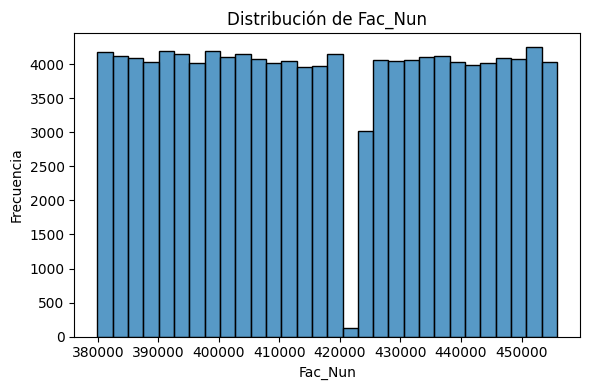

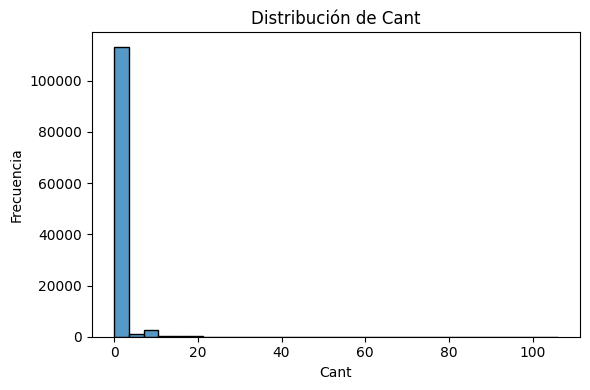

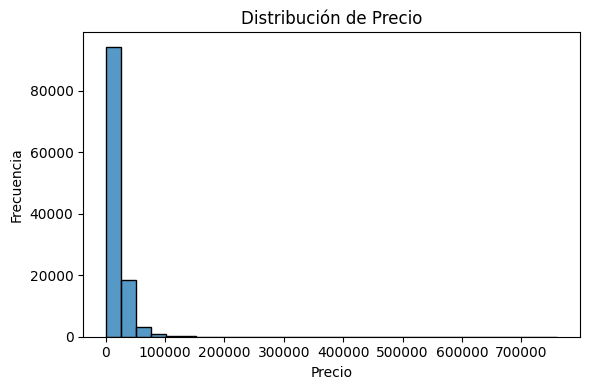

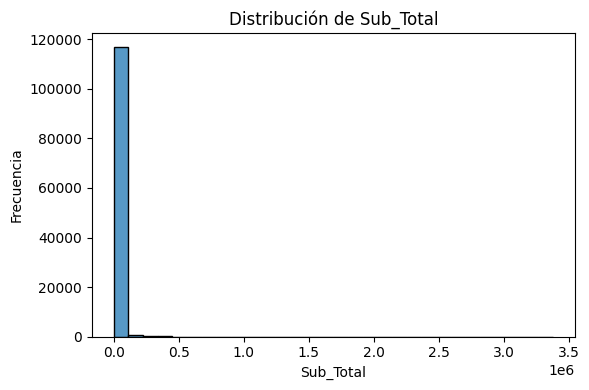

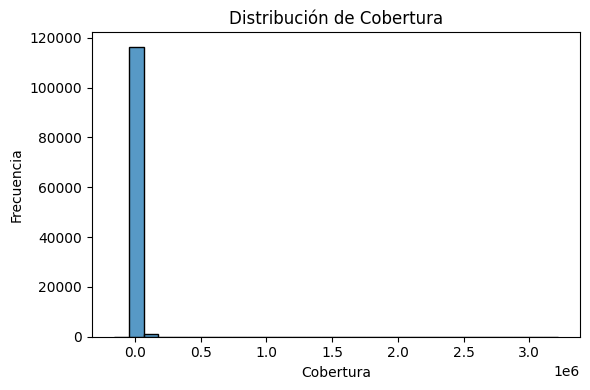

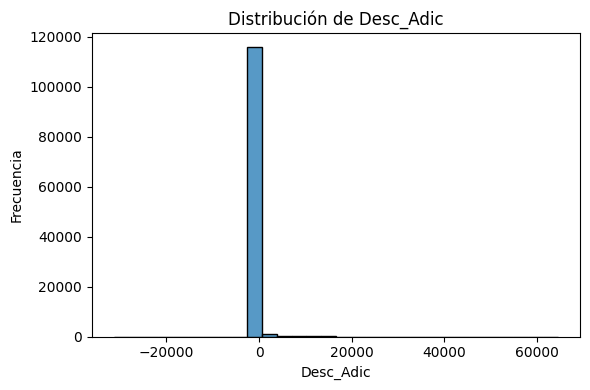

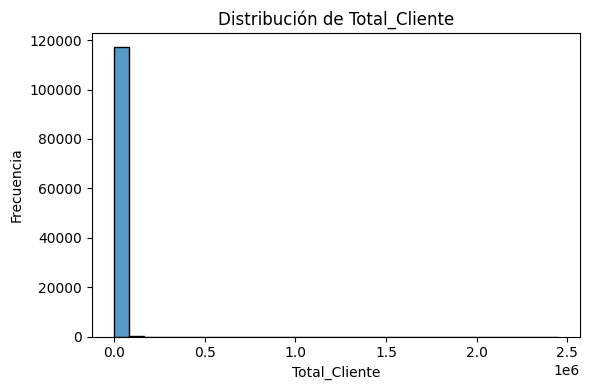

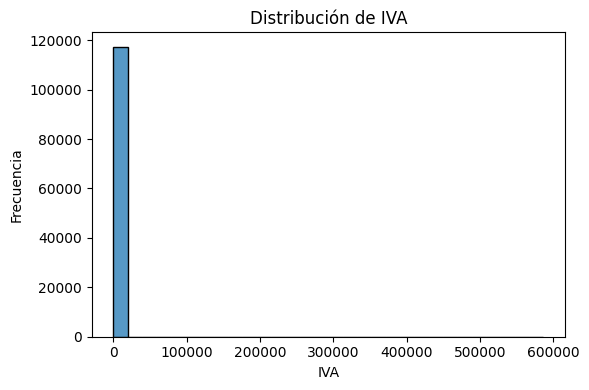

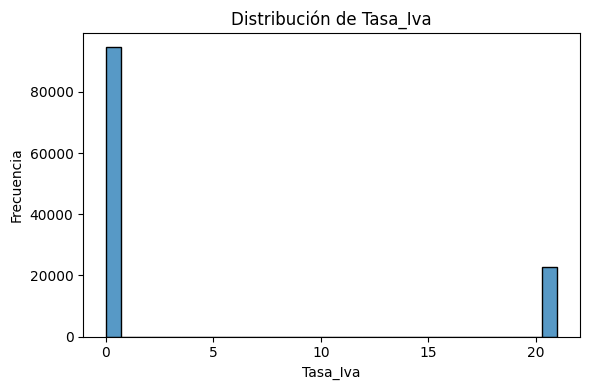

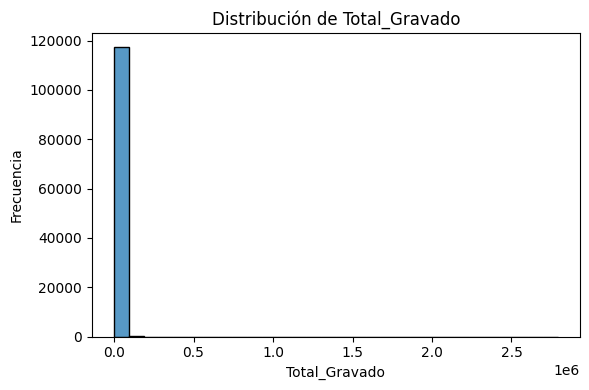

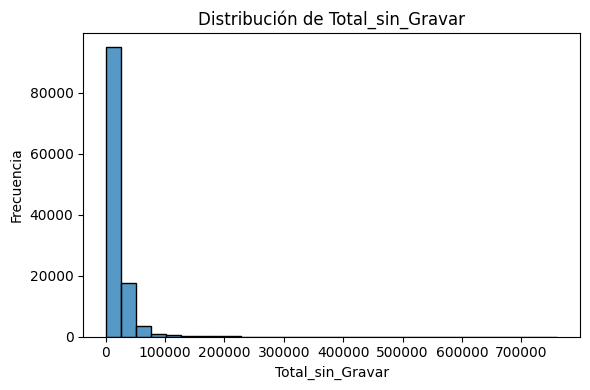

In [355]:
for col in numerical_variables.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

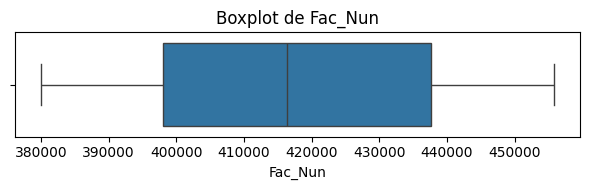

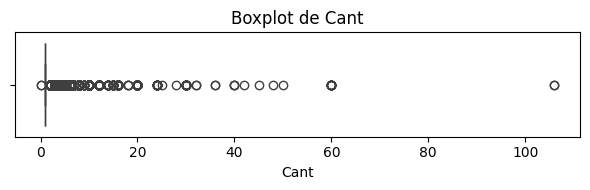

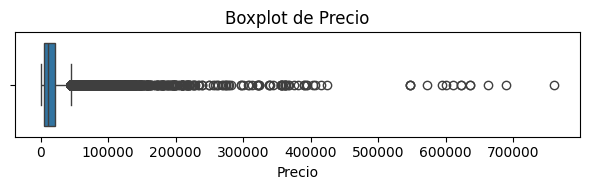

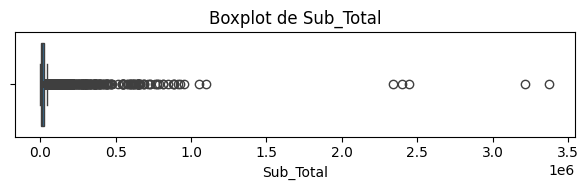

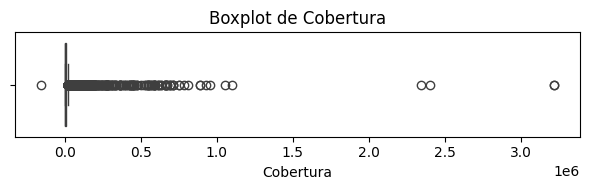

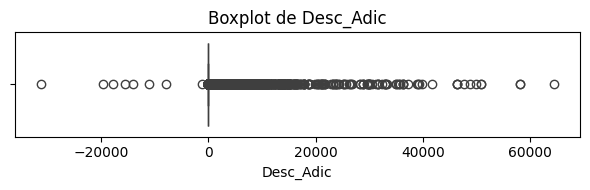

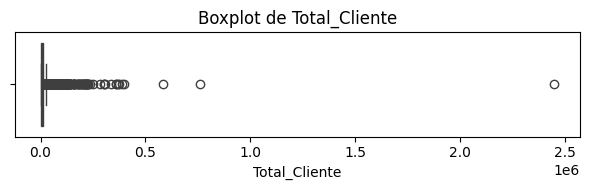

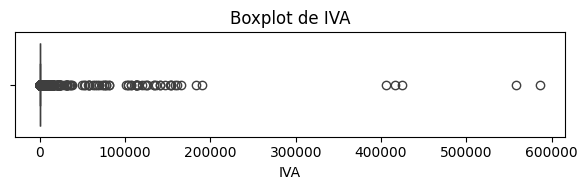

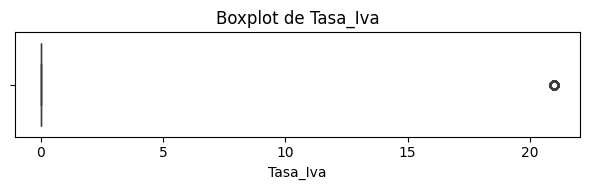

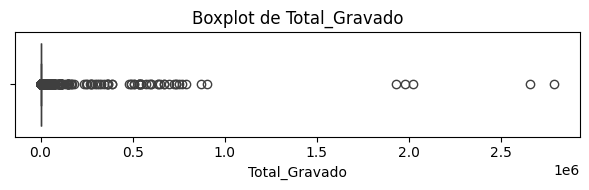

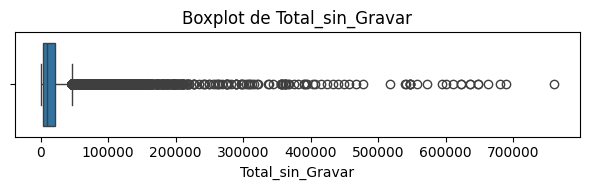

In [356]:
for col in numerical_variables.columns:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()

In [357]:
df.loc[df['Cant'] > 50, ['Fecha', 'Fac_Tipo', 'Producto', 'Cant']]

,Fecha,Fac_Tipo,Producto,Cant
2190,2025-01-07 16:16:24,B,ENSURE ADVANCE LIQUIDO frutilla bot. x 220 ml,60
3001,2025-01-09 15:36:43,B,ENSURE PLUS vainilla env.x 220 ml,60
4521,2025-01-13 18:13:59,B,ENSURE ADVANCE LIQUIDO frutilla bot. x 220 ml,60
14340,2025-02-12 14:42:34,B,ENSURE PLUS vainilla env.x 220 ml,60
16565,2025-02-18 16:03:58,B,ENSURE PLUS FRUTILLA 220 ML,60
25463,2025-03-17 17:38:05,B,ENSURE ADVANCE LIQUIDO cafÑ botella x 220 ml,60
36775,2025-04-16 15:44:30,B,ENSURE PLUS vainilla env.x 220 ml,60
38911,2025-04-23 15:54:06,B,ENSURE PLUS frutilla env.x 220 ml,60
47947,2025-05-19 15:59:52,B,ENSURE PLUS frutilla env.x 220 ml,60
48731,2025-05-21 15:02:04,B,ENSURE PLUS vainilla env.x 220 ml,60


In [358]:
df.loc[df['Precio'] > 500000]

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form,product_name,groups
4453,2025-01-13 16:19:18,B,382628,1,547557.61,MIRENA dispos.intrauterino x 1,547557.61,FARMACIA,547557.61,0.0,0.00,0.0,0.0,0.0,547557.61,MIRENA,Otros,mirena disposintrauterino x 1,Ginecológico / Salud Femenina
5224,2025-01-15 13:53:53,B,383086,1,547557.61,MIRENA dispos.intrauterino x 1,547557.61,FARMACIA,547557.61,0.0,0.00,0.0,0.0,0.0,547557.61,MIRENA,Otros,mirena disposintrauterino x 1,Ginecológico / Salud Femenina
15357,2025-02-14 18:35:58,B,389421,1,547557.61,MIRENA dispos.intrauterino x 1,547557.61,FARMACIA,547557.61,0.0,0.00,0.0,0.0,0.0,547557.61,MIRENA,Otros,mirena disposintrauterino x 1,Ginecológico / Salud Femenina
33524,2025-04-08 10:43:50,B,400545,1,573034.37,KYLEENA dispos.intrauterino x1,573034.37,FARMACIA,573034.37,0.0,0.00,0.0,0.0,0.0,573034.37,KYLEENA,Otros,kyleena disposintrauterino x1,Otros
47932,2025-05-19 15:54:43,B,409483,1,594236.64,MIRENA dispos.intrauterino x 1,594236.64,FARMACIA,594236.64,0.0,0.00,0.0,0.0,0.0,594236.64,MIRENA,Otros,mirena disposintrauterino x 1,Ginecológico / Salud Femenina
71754,2025-08-06 13:12:39,B,427492,1,600093.42,AJOVY 225 mg jga.prell. x 1,600093.42,FARMACIA,591108.57,0.0,8984.85,0.0,0.0,0.0,600093.42,AJOVY,Otros,ajovy 225 mg jgaprell x 1,Nutrición y Suplementos
71970,2025-08-06 18:57:03,B,427618,1,623092.78,MIRENA dispos.intrauterino x 1,623092.78,FARMACIA,623092.78,0.0,0.00,0.0,0.0,0.0,623092.78,MIRENA,Otros,mirena disposintrauterino x 1,Ginecológico / Salud Femenina
72557,2025-08-08 15:10:42,B,427980,1,635554.63,MIRENA dispos.intrauterino x 1,635554.63,FARMACIA,635554.63,0.0,0.00,0.0,0.0,0.0,635554.63,MIRENA,Otros,mirena disposintrauterino x 1,Ginecológico / Salud Femenina
82165,2025-09-05 19:34:38,B,433986,1,610895.10,AJOVY 225 mg jga.prell. x 1,610895.10,FARMACIA,610895.10,0.0,0.00,0.0,0.0,0.0,610895.10,AJOVY,Otros,ajovy 225 mg jgaprell x 1,Nutrición y Suplementos
92485,2025-10-08 17:55:56,B,440377,1,622502.11,AJOVY 225 mg jga.prell. x 1,622502.11,FARMACIA,610895.10,0.0,11607.01,0.0,0.0,0.0,622502.11,AJOVY,Otros,ajovy 225 mg jgaprell x 1,Nutrición y Suplementos


##### Observaciones:
> Se filtraron las variables **cantidad y precio** con el objetivo de identificar posibles outliers. En el análisis de la variable **cantidad**, se observó que los valores extremos corresponden a información real y relevante, principalmente asociada a productos de alta rotación como alimentos para bebés y productos dietéticos para personas con diabetes. Por este motivo, se decidió **no eliminar** estos registros.   
>
> Al analizar la variable **precio**, se detectó que los valores más elevados están mayoritariamente asociados a productos como dispositivos intrauterinos o jeringas precargadas. Mediante un estudio de precios se verificó que dichos valores corresponden al precio real de mercado de estos productos, por lo que se decidió **conservar estos datos**.   

In [362]:
df = df.copy()

In [369]:
df = (df.groupby(['groups', 'Fecha'], as_index=False)
         .agg({'Cant': 'sum'}))

df['Fecha'] = pd.to_datetime(df['Fecha'])

In [370]:
df = df.sort_values(['groups', 'Fecha'])

In [371]:
# To create calendar features
df['week_day'] = df['Fecha'].dt.dayofweek
df['month'] = df['Fecha'].dt.month
df['month_day'] = df['Fecha'].dt.day
df['weekend'] = df['week_day'].isin([5,6]).astype(int)
df['beginning_month'] = (df['month_day'] <= 10).astype(int)

In [372]:
# To create features from the past
for lag in [1, 7, 14, 30]:
    df[f'cant_lag_{lag}'] = df.groupby('groups')['Cant'].shift(lag)

In [373]:
# The average of the last 7 and 30 days
df['rolling_7'] = df.groupby('groups')['Cant'].transform(lambda x: x.shift(1).rolling(7).mean())
df['rolling_30'] = df.groupby('groups')['Cant'].transform(lambda x: x.shift(1).rolling(30).mean())

In [375]:
df.head(10)

,groups,Fecha,Cant,week_day,month,month_day,weekend,beginning_month,cant_lag_1,cant_lag_7,cant_lag_14,cant_lag_30,rolling_7,rolling_30
0,Accesorios y Dispositivos Médicos,2025-01-01 06:06:42,1,2,1,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,Accesorios y Dispositivos Médicos,2025-01-01 07:46:36,2,2,1,1,0,1,1.0,NaN,NaN,NaN,NaN,NaN
2,Accesorios y Dispositivos Médicos,2025-01-02 08:44:01,4,3,1,2,0,1,2.0,NaN,NaN,NaN,NaN,NaN
3,Accesorios y Dispositivos Médicos,2025-01-02 12:01:22,1,3,1,2,0,1,4.0,NaN,NaN,NaN,NaN,NaN
4,Accesorios y Dispositivos Médicos,2025-01-02 12:12:57,1,3,1,2,0,1,1.0,NaN,NaN,NaN,NaN,NaN
5,Accesorios y Dispositivos Médicos,2025-01-02 13:05:34,1,3,1,2,0,1,1.0,NaN,NaN,NaN,NaN,NaN
6,Accesorios y Dispositivos Médicos,2025-01-02 13:19:36,1,3,1,2,0,1,1.0,NaN,NaN,NaN,NaN,NaN
7,Accesorios y Dispositivos Médicos,2025-01-02 13:19:44,5,3,1,2,0,1,1.0,1.0,NaN,NaN,1.571429,NaN
8,Accesorios y Dispositivos Médicos,2025-01-02 14:21:29,1,3,1,2,0,1,5.0,2.0,NaN,NaN,2.142857,NaN
9,Accesorios y Dispositivos Médicos,2025-01-02 17:29:19,3,3,1,2,0,1,1.0,4.0,NaN,NaN,2.000000,NaN


In [377]:
# To remove NaN
df = df.dropna().reset_index(drop=True)

In [378]:
df['groups_encoded'] = df['groups'].astype('category').cat.codes

In [379]:
df.columns

Index(['groups', 'Fecha', 'Cant', 'week_day', 'month', 'month_day', 'weekend',
       'beginning_month', 'cant_lag_1', 'cant_lag_7', 'cant_lag_14',
       'cant_lag_30', 'rolling_7', 'rolling_30', 'groups_encoded'],
      dtype='object')

In [380]:
df.to_csv("../data/processed/df", index=False)